# News Category Classification

## Stage 1. Problem Statement

The dataset contains news articles with their corresponding categories.

The goal of this project is to train a machine learning model that predicts
the category of a news article based on its textual content.

This is a supervised multiclass text classification problem.

### Why this task is useful

Automatic news classification is a Natural Language Processing (NLP) task.
It can be used to automatically organize large collections of news articles,
making them easier to search, filter, and process.

### Evaluation Metrics

The dataset contains multiple classes with an imbalanced class distribution.
Therefore, the main evaluation metric will be **Macro F1**, while **Accuracy**
will be used as an additional metric.

**Accuracy** measures the proportion of correctly classified examples:

Accuracy = Number of correct predictions / Total number of predictions

**F1-score** combines Precision and Recall:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

For multiclass classification, **Macro F1** is calculated by computing the
F1-score independently for each class and then taking their average.

This gives every class equal importance regardless of how many examples it contains.

In [60]:
from datasets import load_dataset

dataset = load_dataset("heegyu/news-category-dataset")

In [61]:
dataset

DatasetDict({
    train: Dataset({
        features: ['link', 'headline', 'category', 'short_description', 'authors', 'date'],
        num_rows: 209527
    })
})

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

df = dataset["train"].to_pandas()

## Stage 2. Data Analysis

Before preparing the data and training a model, we first explore the dataset
to understand its structure and identify potential data quality issues.

During this stage we will:

- inspect the dataset structure and several examples;
- check for missing and empty values;
- check for duplicated articles and conflicting labels;
- examine the number and distribution of target classes;
- analyze the length of the article text;
- inspect the date range of the dataset.

No data will be modified at this stage. The goal is to identify potential
problems that should be addressed during data preparation.

### Dataset Overview

In [63]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype        
---  ------             --------------   -----        
 0   link               209527 non-null  str          
 1   headline           209527 non-null  str          
 2   category           209527 non-null  str          
 3   short_description  209527 non-null  str          
 4   authors            209527 non-null  str          
 5   date               209527 non-null  datetime64[s]
dtypes: datetime64[s](1), str(5)
memory usage: 71.2 MB


In [65]:
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Columns: {df.columns.tolist()}")

Number of rows: 209527
Number of columns: 6
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']


### Missing and Empty Values

In [66]:
df.isna().sum()

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

In [67]:
text_columns = [
    "link",
    "headline",
    "category",
    "short_description",
    "authors",
]

for column in text_columns:
    empty_count = df[column].fillna("").str.strip().eq("").sum()
    print(f"{column}: {empty_count} empty values")

link: 0 empty values
headline: 6 empty values
category: 0 empty values
short_description: 19712 empty values
authors: 37418 empty values


We check whether any articles contain no textual information in either
`headline` or `short_description`.

In [68]:
empty_texts = (
    df["headline"].fillna("").str.strip().eq("")
    & df["short_description"].fillna("").str.strip().eq("")
)

print(f"Articles without text: {empty_texts.sum()}")

df.loc[empty_texts]

Articles without text: 5


,link,headline,category,short_description,authors,date
90944,https://www.huffingtonpost.com/entry/lincoln-2...,,POLITICS,,"Robert Moran, ContributorRobert Moran leads Br...",2015-08-22
103675,https://www.huffingtonpost.com/entry/us-and-eu...,,WORLDPOST,,"Natasha Srdoc, ContributorAuthor, Economist, C...",2015-03-29
109100,https://www.huffingtonpost.com/entry/disney-ce...,,BUSINESS,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-25
110153,https://www.huffingtonpost.com/entry/beverly-h...,,MEDIA,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-13
122145,https://www.huffingtonpost.com/entry/beverly-h...,,QUEER VOICES,,"Gary Snyder, ContributorWriter and Media Strat...",2014-08-28


### Duplicates and Conflicting Labels

Duplicated articles may cause data leakage if identical texts appear in both
training and evaluation sets. We therefore check for duplicated texts and
whether identical texts have conflicting category labels.

In [69]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")

Fully duplicated rows: 13


In [70]:
text_duplicates = df.duplicated(
    subset=["headline", "short_description"]
).sum()

print(f"Duplicated articles: {text_duplicates}")

Duplicated articles: 489


In [71]:
conflicting_duplicates = (
    df.groupby(["headline", "short_description"])["category"]
    .nunique()
    .reset_index(name="category_count")
)

conflicting_duplicates = conflicting_duplicates[
    conflicting_duplicates["category_count"] > 1
]

print(f"Conflicting duplicated texts: {len(conflicting_duplicates)}")

Conflicting duplicated texts: 15


In [72]:
conflicting_rows = df.merge(
    conflicting_duplicates[["headline", "short_description"]],
    on=["headline", "short_description"],
    how="inner",
)

conflicting_rows[
    ["headline", "short_description", "category"]
].sort_values(["headline", "short_description"])

,headline,short_description,category
6,,,POLITICS
9,,,WORLDPOST
10,,,BUSINESS
11,,,MEDIA
13,,,QUEER VOICES
27,A Conversation With Decorator and Fashion Desi...,Much like the arresting color combinations she...,HOME & LIVING
28,A Conversation With Decorator and Fashion Desi...,Much like the arresting color combinations she...,STYLE & BEAUTY
18,Bring Back Our Girls,,WOMEN
19,Bring Back Our Girls,,IMPACT
26,Could You Go a Year Without Buying Anything Ne...,There is one thing that sets me apart from the...,STYLE & BEAUTY


### Class Distribution

In [73]:
categories = df["category"].unique()

print(f"Number of categories: {len(categories)}")
print(categories)

Number of categories: 42
<ArrowStringArray>
[     'U.S. NEWS',         'COMEDY',      'PARENTING',     'WORLD NEWS',
 'CULTURE & ARTS',           'TECH',         'SPORTS',  'ENTERTAINMENT',
       'POLITICS',     'WEIRD NEWS',    'ENVIRONMENT',      'EDUCATION',
          'CRIME',        'SCIENCE',       'WELLNESS',       'BUSINESS',
 'STYLE & BEAUTY',   'FOOD & DRINK',          'MEDIA',   'QUEER VOICES',
  'HOME & LIVING',          'WOMEN',   'BLACK VOICES',         'TRAVEL',
          'MONEY',       'RELIGION',  'LATINO VOICES',         'IMPACT',
       'WEDDINGS',        'COLLEGE',        'PARENTS', 'ARTS & CULTURE',
          'STYLE',          'GREEN',          'TASTE', 'HEALTHY LIVING',
  'THE WORLDPOST',      'GOOD NEWS',      'WORLDPOST',          'FIFTY',
           'ARTS',        'DIVORCE']
Length: 42, dtype: str


In [74]:
class_counts = df["category"].value_counts()

class_counts

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [75]:
class_distribution = df["category"].value_counts(normalize=True) * 100

class_distribution

category
POLITICS          16.991605
WELLNESS           8.564529
ENTERTAINMENT      8.286283
TRAVEL             4.724928
STYLE & BEAUTY     4.683883
PARENTING          4.195641
HEALTHY LIVING     3.194815
QUEER VOICES       3.029204
FOOD & DRINK       3.025863
BUSINESS           2.859775
COMEDY             2.577233
SPORTS             2.423077
BLACK VOICES       2.187308
HOME & LIVING      2.061787
PARENTS            1.887585
THE WORLDPOST      1.748701
WEDDINGS           1.743451
WOMEN              1.704792
CRIME              1.700020
IMPACT             1.662793
DIVORCE            1.635111
WORLD NEWS         1.574499
MEDIA              1.405070
WEIRD NEWS         1.325366
GREEN              1.251390
WORLDPOST          1.230868
RELIGION           1.229913
STYLE              1.075756
SCIENCE            1.052848
TECH               1.004167
TASTE              1.000348
MONEY              0.838078
ARTS               0.720194
ENVIRONMENT        0.689171
FIFTY              0.668649
GOOD NEWS  

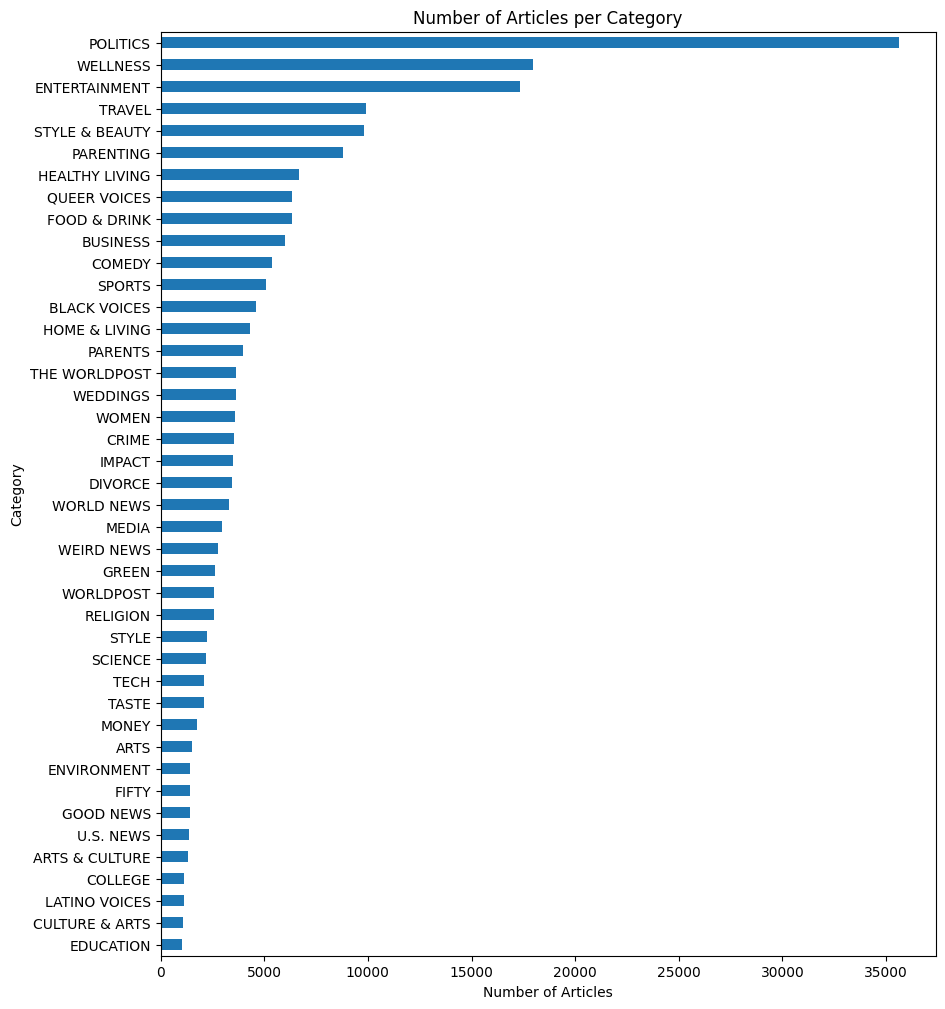

In [76]:
class_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 12),
)

plt.title("Number of Articles per Category")
plt.xlabel("Number of Articles")
plt.ylabel("Category")
plt.show()

### Text Length

In [77]:
df["text"] = (
    df["headline"].fillna("")
    + " "
    + df["short_description"].fillna("")
)

df["text_length"] = df["text"].str.split().str.len()

df["text_length"].describe()

count    209527.000000
mean         29.269770
std          13.803927
min           0.000000
25%          20.000000
50%          28.000000
75%          35.000000
max         245.000000
Name: text_length, dtype: float64

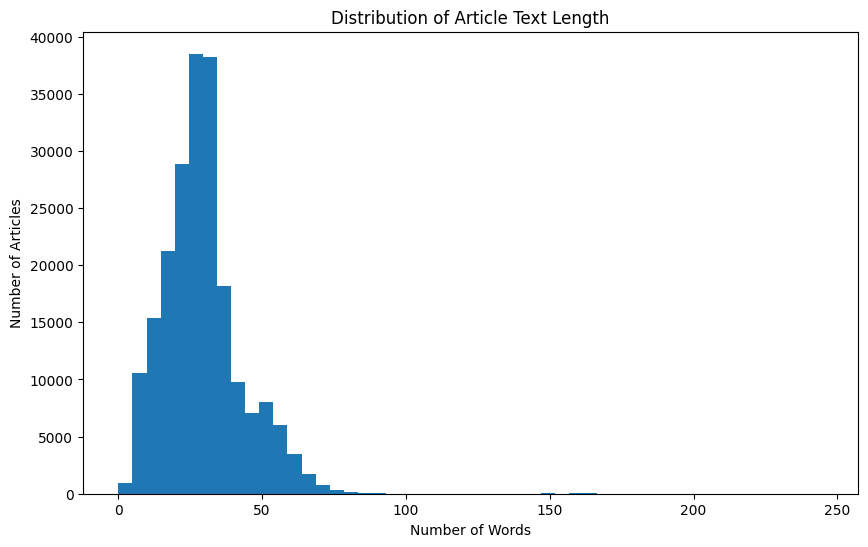

In [78]:
df["text_length"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 6),
)

plt.title("Distribution of Article Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.show()

### Date Range

In [79]:
dates = pd.to_datetime(df["date"])

print(f"From: {dates.min()}")
print(f"To:   {dates.max()}")

From: 2012-01-28 00:00:00
To:   2022-09-23 00:00:00


### Data Analysis Conclusions

The dataset contains **209,527 news articles** and 6 original columns:
`link`, `headline`, `category`, `short_description`, `authors`, and `date`.

No NaN values were found. However, some textual fields contain empty strings:

- `headline`: 6 empty values;
- `short_description`: 19,712 empty values;
- `authors`: 37,418 empty values.

There are **5 articles where both `headline` and `short_description` are empty**.
These examples contain no textual information that can be used for classification
and will need to be handled during data preparation.

The dataset contains:

- 13 fully duplicated rows;
- 489 repeated `headline + short_description` entries;
- 15 groups of identical texts assigned to more than one category.

The conflicting labels represent a data quality issue that should be resolved
before splitting and training the model.

The target variable `category` contains **42 classes**.
The class distribution is noticeably imbalanced. The largest class, `POLITICS`,
contains 35,602 examples (about 17% of the dataset), while the smallest class,
`EDUCATION`, contains 1,014 examples (about 0.48%).

Because of this imbalance, class-wise performance and Macro F1 will be important
when evaluating the model.

For the combined `headline + short_description` text:

- mean length: about 29 words;
- median length: 28 words;
- 75% of articles contain no more than 35 words;
- maximum length: 245 words.

These values represent whitespace-separated words rather than tokenizer tokens.
The actual token sequence lengths will be analyzed later when a tokenizer is selected.

The articles cover the period from **January 28, 2012 to September 23, 2022**.